In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
data = pd.read_csv("example_data.csv")
data

,f_res,max_power_dBm
0,3000,-54.0
1,3002,-54.1
2,3004,-54.0
3,3006,-53.9
4,3008,-53.8
...,...,...
996,4992,-63.8
997,4994,-63.3
998,4996,-63.3
999,4998,-63.8


Text(0.5, 1.0, 'Power vs Freq.')

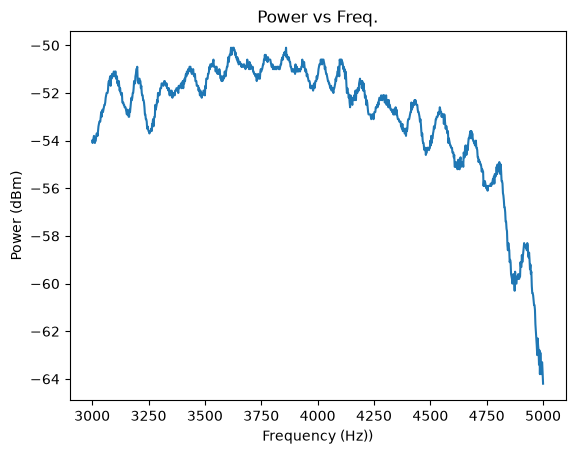

In [ ]:
x = data['f_res'].values
y = data['max_power_dBm'].values

plot1 = plt.plot(x,y)
plt.xlabel("Frequency (Hz))")
plt.ylabel("Power (dBm)")
plt.title("Power vs Freq.")

Text(0.5, 1.0, 'Power vs Freq.')

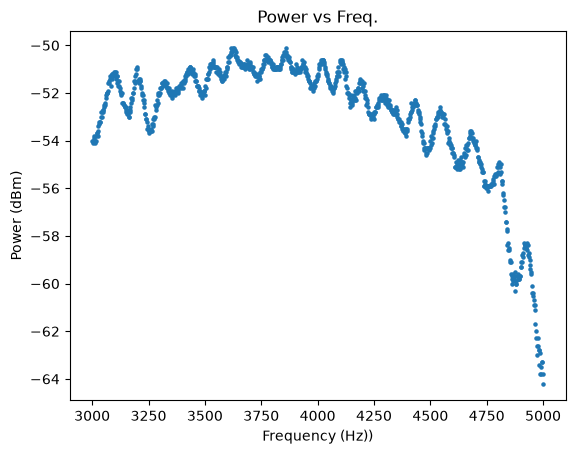

In [11]:
plot2 = plt.scatter(x,y,s=5)
plt.xlabel("Frequency (Hz))")
plt.ylabel("Power (dBm)")
plt.title("Power vs Freq.")

In [12]:
power_mW = 10 ** (np.array(y)/10) # y is the power in dBm

print (power_mW[:5])


[3.98107171e-06 3.89045145e-06 3.98107171e-06 4.07380278e-06
 4.16869383e-06]


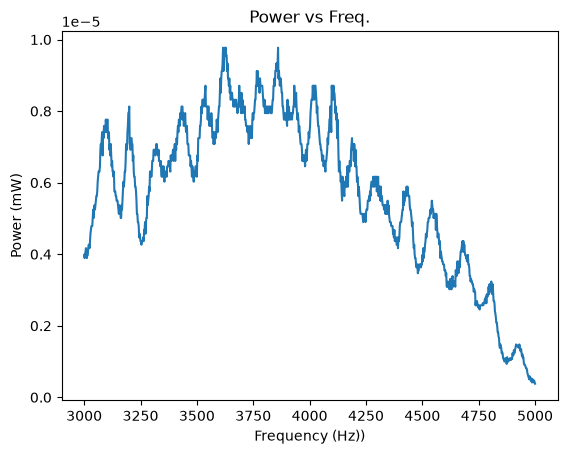

In [14]:
plt.plot(x,power_mW)
plt.xlabel("Frequency (Hz))")
plt.ylabel("Power (mW)")
plt.title("Power vs Freq.")
plt.show()

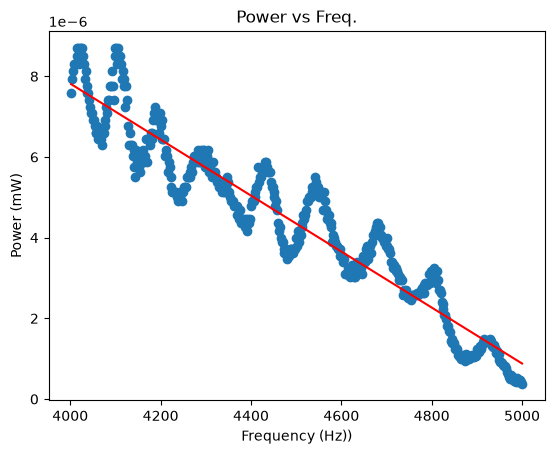

[9.71175456e-11 4.38024185e-07]


In [28]:
frequency = x
mask = frequency > 4000
freq_trim = frequency[mask]
power_trim = power_mW[mask]

def linear_fit(x,m,b):
    return m*x + b

popt, pcov = curve_fit(linear_fit, freq_trim, power_trim, p0 = (-1, 40e-6))
perr = np.sqrt(np.diag(pcov))

plt.scatter(freq_trim,power_trim)
plt.plot(freq_trim, linear_fit(freq_trim, popt[0],popt[1]), color='red')
plt.xlabel("Frequency (Hz))")
plt.ylabel("Power (mW)")
plt.title("Power vs Freq.")
plt.show()

print(perr)
